In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import rasterio
from rasterio.warp import reproject, Resampling
from rasterio.transform import from_bounds

In [2]:


# SpaFHy model output (NetCDF with inflow_to_ditch variable)
NC_FILE = r"C:\Parvizi\DTS\Input\spafhy_input\pallas\results\pallas_analysis_2_2D_202602181223\202602181222_inflow_to_ditch_pos.nc"# UPDATE THIS

# TIFF stream classification (0=background, 1=main, 2=tributary, 3=ditch)
TIFF_FILE = r"C:\Parvizi\Documents\ArcGIS\Projects\SpaFHy-Pallas\LJOSPAFHYnetwork.tif"

# Output CSV file
OUTPUT_CSV = r"C:\Parvizi\DTS\Clone_DTS\Final-Final-Clone DTS Article\Final Version of DTS Article Codes to Push\DTS_analysis_LJO\lateral_inflows_for_DTS_Monthly.csv"

# STREAM CLASS VALUES (from TIFF)

MAIN_CLASS = 1
TRIBUTARY_CLASS = 2
DITCH_CLASS = 3


# CONFLUENCE POSITIONS (meters along stream)

DITCH_POSITION_M = 650      # Ditch enters main stream at ~650m
TRIBUTARY_POSITION_M = 1470  # Tributary enters main stream at ~1470m


# ANALYSIS DATES

ANALYSIS_DATES = {
    'February': '2023-02-11',
    'April': '2023-04-03',
    'May': '2023-05-17',
    'June': '2023-06-30',
    'July': '2023-07-12',
    'August': '2023-08-23'
}

In [3]:
# Load SpaFHy model results
results = xr.open_dataset(NC_FILE)

# Get inflow variable (create from netflow if needed)
if 'inflow_to_ditch' in results.data_vars:
    inflow_data = results['inflow_to_ditch']
else:
    # Use positive values only from deep_netflow_to_ditch
    netflow = results['deep_netflow_to_ditch']
    inflow_data = netflow.where(netflow > 0, 0)

# Model grid info
model_shape = (len(results.lat), len(results.lon))
model_lats = results.lat.values
model_lons = results.lon.values

print(f"Model grid: {model_shape}")
print(f"Time range: {pd.Timestamp(results.time.values[0]).date()} to {pd.Timestamp(results.time.values[-1]).date()}")

Model grid: (221, 136)
Time range: 2019-01-01 to 2023-12-31


In [4]:
# Load TIFF stream classification
with rasterio.open(TIFF_FILE) as src:
    tiff_data = src.read(1)
    tiff_transform = src.transform
    tiff_crs = src.crs

print(f"TIFF shape: {tiff_data.shape}")

# Resample TIFF to match model grid if needed
if tiff_data.shape != model_shape:
    print(f"Resampling TIFF from {tiff_data.shape} to {model_shape}...")
    
    # Get model bounds
    model_bounds = (
        float(model_lons.min()),
        float(model_lats.min()),
        float(model_lons.max()),
        float(model_lats.max())
    )
    
    # Create target transform
    target_transform = from_bounds(*model_bounds, model_shape[1], model_shape[0])
    
    # Resample using nearest neighbor (preserves class values)
    stream_classes = np.zeros(model_shape, dtype=tiff_data.dtype)
    reproject(
        source=tiff_data,
        destination=stream_classes,
        src_transform=tiff_transform,
        src_crs=tiff_crs,
        dst_transform=target_transform,
        dst_crs=tiff_crs,
        resampling=Resampling.nearest
    )
else:
    stream_classes = tiff_data.copy()

# Count pixels by class
print(f"\nStream classification:")
print(f"  Main Stream (class {MAIN_CLASS}): {np.sum(stream_classes == MAIN_CLASS)} pixels")
print(f"  Tributary (class {TRIBUTARY_CLASS}):   {np.sum(stream_classes == TRIBUTARY_CLASS)} pixels")
print(f"  Ditch (class {DITCH_CLASS}):       {np.sum(stream_classes == DITCH_CLASS)} pixels")

TIFF shape: (195, 83)
Resampling TIFF from (195, 83) to (221, 136)...

Stream classification:
  Main Stream (class 1): 271 pixels
  Tributary (class 2):   217 pixels
  Ditch (class 3):       319 pixels


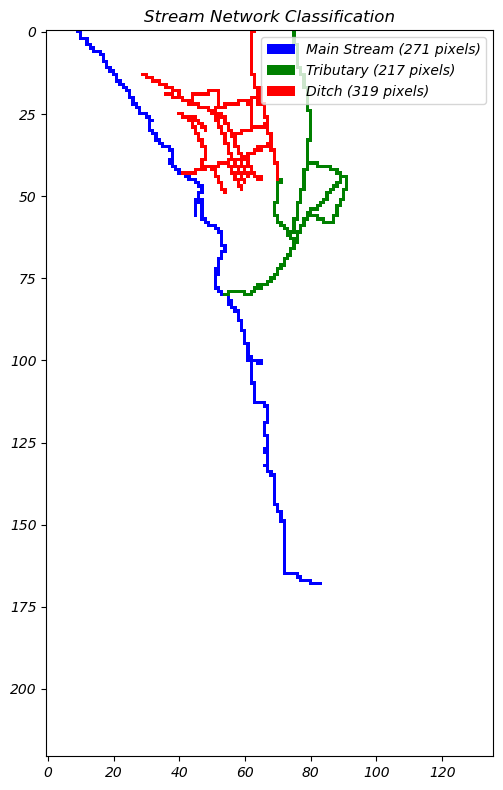

In [5]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

# Visualize stream classification
fig, ax = plt.subplots(figsize=(10, 8))

# Create colormap for classification
colors = ['white', 'blue', 'green', 'red']  # 0=background, 1=main, 2=trib, 3=ditch
cmap = ListedColormap(colors)
bounds = [-0.5, 0.5, 1.5, 2.5, 3.5]
norm = BoundaryNorm(bounds, cmap.N)

im = ax.imshow(stream_classes, cmap=cmap, norm=norm)

# Add legend
legend_elements = [
    Patch(facecolor='blue', label=f'Main Stream ({np.sum(stream_classes == 1)} pixels)'),
    Patch(facecolor='green', label=f'Tributary ({np.sum(stream_classes == 2)} pixels)'),
    Patch(facecolor='red', label=f'Ditch ({np.sum(stream_classes == 3)} pixels)')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=10)

# Add confluence markers
ax.set_title('Stream Network Classification', fontsize=12)

plt.tight_layout()


In [6]:
def get_time_indices_for_month(results, year, month):
    """Return all time indices that fall in the given (year, month)."""
    indices = []
    for i in range(len(results.time)):
        ts = pd.Timestamp(results.time[i].values)
        if ts.year == year and ts.month == month:
            indices.append(i)
    return indices

# Create masks for tributary and ditch
trib_mask = (stream_classes == TRIBUTARY_CLASS)
ditch_mask = (stream_classes == DITCH_CLASS)

thr = 0.0  # active cells: strictly positive inflow

# Extract monthly mean and median inflows (over all days in each month)
lateral_inflows = []

for month_name, date_str in ANALYSIS_DATES.items():
    # Get (year, month) from the reference date
    ref = pd.Timestamp(date_str)
    year, month = ref.year, ref.month

    indices = get_time_indices_for_month(results, year, month)
    if len(indices) == 0:
        print(f"Warning: No timesteps found for {month_name} {year}-{month:02d}")
        continue

    # Collect daily mean and daily median (over pixels) for each day in the month
    daily_trib_means = []
    daily_trib_medians = []
    daily_ditch_means = []
    daily_ditch_medians = []

    for idx in indices:
        inflow_2d = inflow_data.values[idx]

        trib_values = inflow_2d[trib_mask]
        ditch_values = inflow_2d[ditch_mask]
        trib_values = trib_values[~np.isnan(trib_values)]
        ditch_values = ditch_values[~np.isnan(ditch_values)]
        trib_active = trib_values[trib_values > thr]
        ditch_active = ditch_values[ditch_values > thr]

        trib_mean = np.mean(trib_active) if len(trib_active) > 0 else 0.0
        trib_median = np.median(trib_active) if len(trib_active) > 0 else 0.0
        ditch_mean = np.mean(ditch_active) if len(ditch_active) > 0 else 0.0
        ditch_median = np.median(ditch_active) if len(ditch_active) > 0 else 0.0

        daily_trib_means.append(trib_mean)
        daily_trib_medians.append(trib_median)
        daily_ditch_means.append(ditch_mean)
        daily_ditch_medians.append(ditch_median)

    # Monthly mean = mean of daily means; monthly median = median of daily medians
    monthly_trib_mean = np.mean(daily_trib_means)
    monthly_trib_median = np.median(daily_trib_medians)
    monthly_ditch_mean = np.mean(daily_ditch_means)
    monthly_ditch_median = np.median(daily_ditch_medians)

    # Date column: first day of month for reference (e.g. 2023-02-01)
    date_label = f"{year}-{month:02d}-01"

    lateral_inflows.append({
        'Month': month_name,
        'Date': date_label,
        'Ditch_Mean_mm_d': round(monthly_ditch_mean, 2),
        'Ditch_Median_mm_d': round(monthly_ditch_median, 2),
        'Ditch_Position_m': DITCH_POSITION_M,
        'Tributary_Mean_mm_d': round(monthly_trib_mean, 2),
        'Tributary_Median_mm_d': round(monthly_trib_median, 2),
        'Tributary_Position_m': TRIBUTARY_POSITION_M
    })

# Create DataFrame
lateral_df = pd.DataFrame(lateral_inflows)
print(f"Extracted monthly mean/median inflows for {len(lateral_df)} months")
lateral_df

Extracted monthly mean/median inflows for 6 months


,Month,Date,Ditch_Mean_mm_d,Ditch_Median_mm_d,Ditch_Position_m,Tributary_Mean_mm_d,Tributary_Median_mm_d,Tributary_Position_m
0,February,2023-02-01,4.140000,1.170000,650,15.650000,11.850000,1470
1,April,2023-04-01,6.280000,2.480000,650,17.760000,13.030000,1470
2,May,2023-05-01,18.540001,16.870001,650,33.119999,32.349998,1470
3,June,2023-06-01,10.960000,9.780000,650,24.770000,22.370001,1470
4,July,2023-07-01,6.550000,5.110000,650,18.330000,15.070000,1470
5,August,2023-08-01,7.110000,4.780000,650,19.809999,14.570000,1470


In [7]:
# Save to CSV
lateral_df.to_csv(OUTPUT_CSV, index=False)
print(f"Saved: {OUTPUT_CSV}")

# Display summary
print("\n" + "="*60)
print("LATERAL INFLOWS FOR DTS ANALYSIS")
print("="*60)
print(f"\nDitch confluence:     {DITCH_POSITION_M} m along stream")
print(f"Tributary confluence: {TRIBUTARY_POSITION_M} m along stream")
print("\n" + lateral_df.to_string(index=False))

Saved: C:\Parvizi\DTS\Clone_DTS\Final-Final-Clone DTS Article\Final Version of DTS Article Codes to Push\DTS_analysis_LJO\lateral_inflows_for_DTS_Monthly.csv

LATERAL INFLOWS FOR DTS ANALYSIS

Ditch confluence:     650 m along stream
Tributary confluence: 1470 m along stream

   Month       Date  Ditch_Mean_mm_d  Ditch_Median_mm_d  Ditch_Position_m  Tributary_Mean_mm_d  Tributary_Median_mm_d  Tributary_Position_m
February 2023-02-01         4.140000           1.170000               650            15.650000              11.850000                  1470
   April 2023-04-01         6.280000           2.480000               650            17.760000              13.030000                  1470
     May 2023-05-01        18.540001          16.870001               650            33.119999              32.349998                  1470
    June 2023-06-01        10.960000           9.780000               650            24.770000              22.370001                  1470
    July 2023-07-01    